<a href="https://colab.research.google.com/github/apanish-cell/Learning-DeepLearning/blob/main/Pytorch_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## PyTorch and Neural Network and ML

## 0. Setup & Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris    # Import Datasets
import torch                              # PyTorch - Tensor Operations
import torch.nn as nn                     # PyTorch - Neural Network
import torch.optim as optim               # PyTorch - Optimizer for weights
torch.manual_seed(42)
np.random.seed(42)


In [ ]:
a = np.array([1.0,2.0,3.0])
print(a)

b = torch.tensor([1.0,2.0,3.0])
print(b)

ab = torch.dot(b,b)
print(ab)

[1. 2. 3.]
tensor([1., 2., 3.])
tensor(14.)


##Loss = (Wx -y)^2


*   y - what you're aiming for
*   Wx - Prediction
*   Loss - how good the prediction was





   
  




In [ ]:
x = torch.tensor(2.0)                      # Input
y = torch.tensor(5.0)                      # Desired Output
w = torch.tensor(1.0, requires_grad=True)  # Weight ---- requires_grad=True: What track the gradient for w

prediction = w*x                            # Forward Pass thru NN
loss = (w*x - y)**2

print(f"prediction = {prediction}\n",
      f"loss = {loss}")

prediction = 2.0
 loss = 9.0


In [ ]:
loss.backward()  # how to update the model to give better output

In [ ]:
print(f"gradient: {w.grad.item():0.02f}") # Gets gradient after calling loss.backward

gradient: -12.00


Gradient Descent

In [ ]:
step = 0.1
with torch.no_grad():      # Gradient step manually
  w -= step * w.grad
  print(w.item())
prediction = w*x
loss = (prediction - y)**2

print(f"prediction = {prediction}\n",
      f"loss = {loss}")

2.200000047683716
prediction = 4.400000095367432
 loss = 0.3599998950958252


## Solving the Problem of Iris Dataset

The Iris dataset is a classic benchmark in ML

# Features (**Inputs**)
Each sample has 4 numerical measurements:

1.   Sepal Length
2.   Sepal Width
3.   Petal Length
4.   Petal Width

# Labels (**Outputs**)
Each flower belongs to 1 of 3 species:


*   0 --> Iris Setosa
*   1 --> Iris Versicolor
*   2 --> Iris Virginica

# Problem Statement:
- Given the 4 measurements of an unseen iris flower, **predict its species**

This is a **multi-class** classification problem with:

*   Input Dimension: 4
*   Output Classes: 3
*   Dataset Size: 150 samples (50/class)




In [ ]:
iris = load_iris()   # Load Dataset

In [ ]:
X_raw = iris.data       # Feautres/Inputs
print(X_raw.shape)

y_raw = iris.target     # Labels/Outputs/Targets
print(y_raw.shape)

(150, 4)
(150,)


In [ ]:
print(y_raw)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [ ]:
feats = iris.feature_names
targs = iris.target_names


print(f"Feature Names: {feats}\n",
      f"Target Names: {targs}\n\n",
      np.bincount(y_raw))

Feature Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
 Target Names: ['setosa' 'versicolor' 'virginica']

 [50 50 50]


Plotting

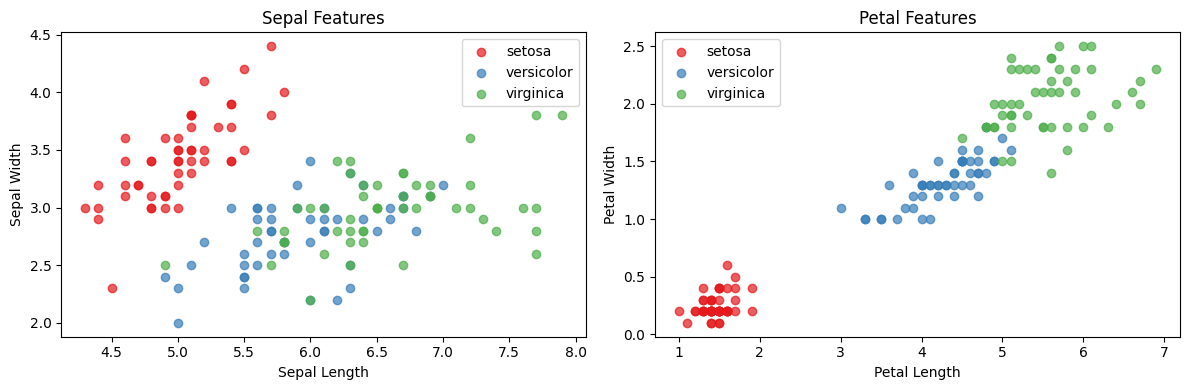

In [ ]:
figs, axes = plt.subplots(1,2, figsize=(12,4))
colors = ['#e41a1c', '#377eb8', '#4daf4a']
for cls in range(3):
  mask = y_raw == cls
  axes[0].scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors[cls], label=iris.target_names[cls], alpha=0.7)
  axes[1].scatter(X_raw[mask,2], X_raw[mask, 3], c=colors[cls], label=iris.target_names[cls], alpha=0.7)

axes[0].set_xlabel('Sepal Length'); axes[0].set_ylabel('Sepal Width')
axes[0].set_title('Sepal Features'); axes[0].legend()
axes[1].set_xlabel('Petal Length'); axes[1].set_ylabel('Petal Width')
axes[1].set_title('Petal Features'); axes[1].legend()
plt.tight_layout()
plt.show()

## Dataloading:

# Splitting Data
*  **Train** - Model Learns from this - 70%
*  **Validation** - Tune hyperparameters, detect overfitting - 15%
*  **Test** - Final unbiased evaluation - touch only once - 15%

# Normalize Data
* NN train much better when input features are on similar scales. We use **StandardScaler**: subtract the mean, divide by standard deviation -> each feature has mean=0, std=1

**Critical**: fit the scaler **only on training data**, the apply to val/test. Never let test statistics leak into training

# PyTorch Data Utilities
* **Dataset**: wraps your data; defines __len__ and __getitem__
* **DataLoader**: batches your dataset, shuffles, handles multi-worker loading

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2, random_state=42)  # Split raw inputs and outputs into 20:80 testing:training
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42)    # Splitting test data 50/50 test/val

print(f"X_train: {X_train.shape}\nx_val: {X_val.shape}\nX_test: {X_test.shape}\n")
print(f"y_train: {y_train.shape}\ny_val: {y_val.shape}\ny_test: {y_test.shape}\n")

X_train: (120, 4)
x_val: (15, 4)
X_test: (15, 4)

y_train: (120,)
y_val: (15,)
y_test: (15,)



In [ ]:
# Standardize Data

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:
X_train.mean(axis=0), X_train.std(axis=0)

(array([ 1.71344420e-15, -1.66579713e-15, -2.23894977e-16, -5.73615229e-17]),
 array([1., 1., 1., 1.]))

## DataLoader

In [ ]:
# Turns Features and Labels into Tensors
from torch.utils.data import Dataset, DataLoader

class IrisDataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32)
    self.y = torch.tensor(y, dtype=torch.long)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [ ]:
train_dataset = IrisDataset(X_train, y_train)
test_dataset = IrisDataset(X_test, y_test)
val_dataset = IrisDataset(X_val, y_val)

In [ ]:
batch_size = 16

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
for (X_batch, y_batch) in train_loader:
  print(f"X_batch: {X_batch.shape} | | y_batch: {y_batch.shape}")

X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([16, 4]) | | y_batch: torch.Size([16])
X_batch: torch.Size([8, 4]) | | y_batch: torch.Size([8])


## Buidling the Model: nn.Module and Linear Layers
# Neural Network Architecture
We'll build a simple fully connected dense feedforward network:

Input (4) --> Hidden Layer 1 (16) [Linear + ReLU] --> Hidden Layer 2 (16) [Linear + ReLU] --> Output (3)



In [ ]:
class IrisClassifier(nn.Module):
  def __init__(self, input_dim=4, hidden_dim=batch_size, output_dim=3):
    super().__init__()

    self.neural_network = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, output_dim)
        #nn.Softmax()
    )
  def forward(self, X):
    return self.neural_network(X)

In [ ]:
model = IrisClassifier()   # The Neural Network

total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params}")


Total Parameters: 403


## Loss Function & Optimizer

**Loss Function:** CrossEntropyLoss
For multi-class classification, we use **Cross-Entroy Loss:**

**Optimizer:** Adam

**Adam:** (Adaptive Moment Estimation) is the most popular optimizer. It improves on basic SGD by:
*  Maintaining per-parameter learning rates
*  Using momentum


In [ ]:
criterion = nn.CrossEntropyLoss()
learning_rate = 0.001
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
# model = model.to('cuda')   # use GPU

In [ ]:
# Training with Training data
def train_one_epoch(model, train_loader, criterion, optimizer):
  model.train()
  total_loss = 0.0
  correct = 0.0
  total = 0.0

  for (X_batch, y_batch) in train_loader:
    optimizer.zero_grad()
    y_pred = model(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y_batch).sum().item()
    total += len(y_batch)

  return total_loss / len(train_loader), correct / total

In [ ]:
@torch.no_grad()
def evaluate(model, val_loader, criterion):
  model.eval()
  total_loss = 0.0
  correct = 0.0
  total = 0.0

  for (X_batch, y_batch) in val_loader:
    y_pred = model(X_batch)
    loss = criterion(y_pred, y_batch)
    total_loss += loss.item()

    preds = torch.argmax(y_pred, dim=1)
    correct += (preds == y_batch).sum().item()
    total += len(y_batch)

  return total_loss/total, correct/total

In [ ]:
num_epochs = 100
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
  train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
  val_loss, val_acc = evaluate(model, val_loader, criterion)
  history['train_loss'].append(train_loss)
  history['train_acc'].append(train_acc)
  history['val_loss'].append(val_loss)
  history['val_acc'].append(val_acc)

  if epoch % 10 ==0 or epoch == 1:
    print(f"Epoch: {epoch}, Train Loss: {train_loss:0.4f}, Train Acc: {train_acc:0.4f}, Val Loss: {val_loss:0.4f}, Val Acc: {val_acc:0.4f}")
print("Training Complete")

Epoch: 0, Train Loss: 1.0965, Train Acc: 0.3250, Val Loss: 0.0727, Val Acc: 0.4000
Epoch: 1, Train Loss: 1.0889, Train Acc: 0.4333, Val Loss: 0.0719, Val Acc: 0.4667
Epoch: 10, Train Loss: 0.9477, Train Acc: 0.8333, Val Loss: 0.0613, Val Acc: 0.9333
Epoch: 20, Train Loss: 0.5950, Train Acc: 0.8750, Val Loss: 0.0382, Val Acc: 0.8000
Epoch: 30, Train Loss: 0.3531, Train Acc: 0.8833, Val Loss: 0.0225, Val Acc: 0.8667
Epoch: 40, Train Loss: 0.2231, Train Acc: 0.9333, Val Loss: 0.0148, Val Acc: 0.8667
Epoch: 50, Train Loss: 0.1450, Train Acc: 0.9500, Val Loss: 0.0073, Val Acc: 1.0000
Epoch: 60, Train Loss: 0.0938, Train Acc: 0.9750, Val Loss: 0.0050, Val Acc: 1.0000
Epoch: 70, Train Loss: 0.0705, Train Acc: 0.9750, Val Loss: 0.0035, Val Acc: 1.0000
Epoch: 80, Train Loss: 0.0614, Train Acc: 0.9917, Val Loss: 0.0027, Val Acc: 1.0000
Epoch: 90, Train Loss: 0.0567, Train Acc: 0.9833, Val Loss: 0.0018, Val Acc: 1.0000
Training Complete


In [ ]:
#_____Test Set Evaluation ____________________________-

test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"Test Loss:     {test_loss:0.4f}\n",
      f"Test Accuracy: {test_acc: 0.1%}")

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
  for X_batch, y_batch in test_loader:
    logits = model(X_batch)
    preds = logits.argmax(dim=1)
    preds = preds.detach().cpu()
    y_batch = y_batch.detach().cpu()
    all_preds.extend(preds.numpy())
    all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

Test Loss:     0.0023
 Test Accuracy:  100.0%


In [ ]:
#____Per-Class Classification Report____________

from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       1.00      1.00      1.00         3
   virginica       1.00      1.00      1.00         7

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15



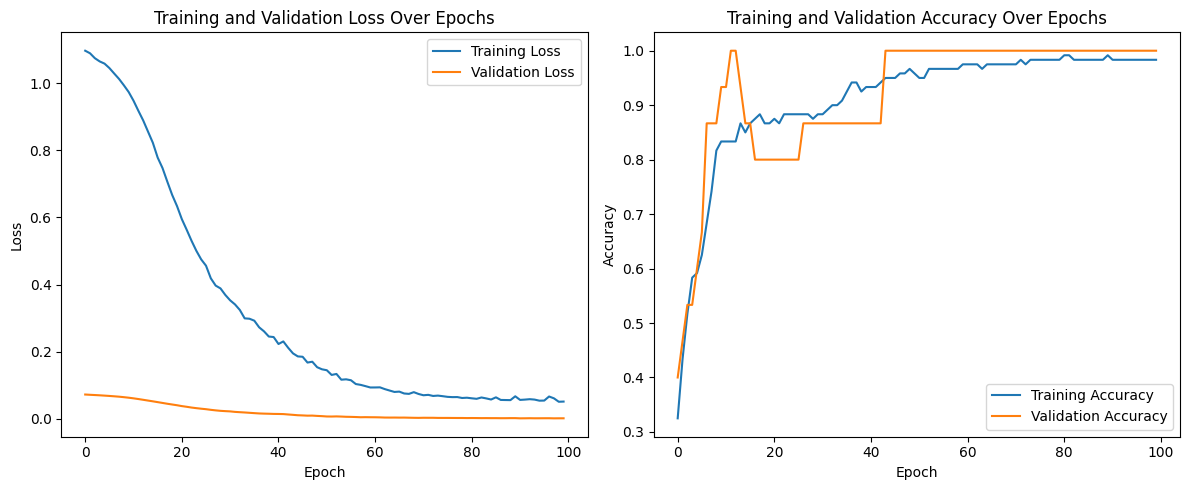

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### Confusion Matrix for Test Set

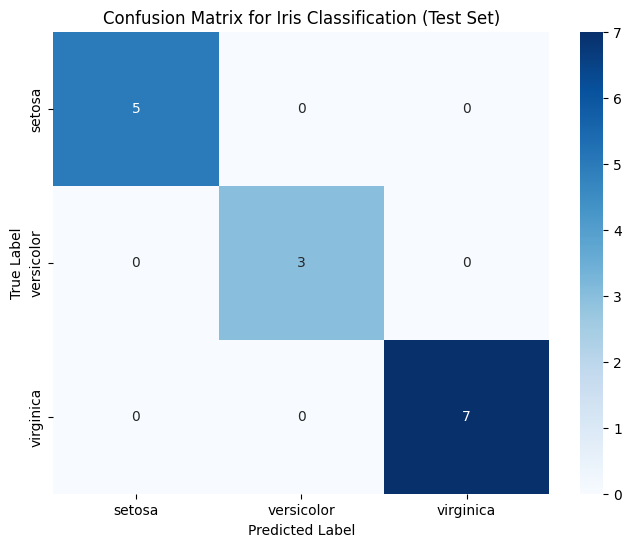

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Iris Classification (Test Set)')
plt.show()

In [ ]:
#reagank@udel.edu